In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("resultados.csv")

# Promediar las 10 iteraciones por configuración
promedios = df.groupby(["tipo", "puntos", "dims", "hilos"])["tiempo_ms"].mean().reset_index()

# Separar serial y paralelo
serial   = promedios[promedios["tipo"] == "serial"][["puntos", "dims", "tiempo_ms"]].rename(columns={"tiempo_ms": "tiempo_serial"})
paralelo = promedios[promedios["tipo"] == "paralelo"]

# Unir por puntos y dims para calcular speedup
merged = paralelo.merge(serial, on=["puntos", "dims"])
merged["speedup"] = merged["tiempo_serial"] / merged["tiempo_ms"]

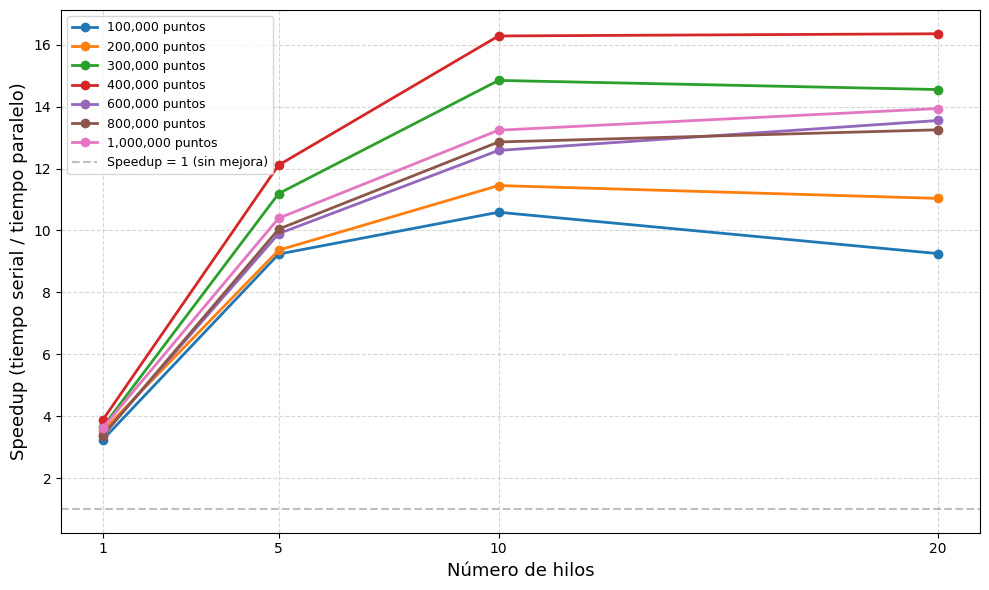

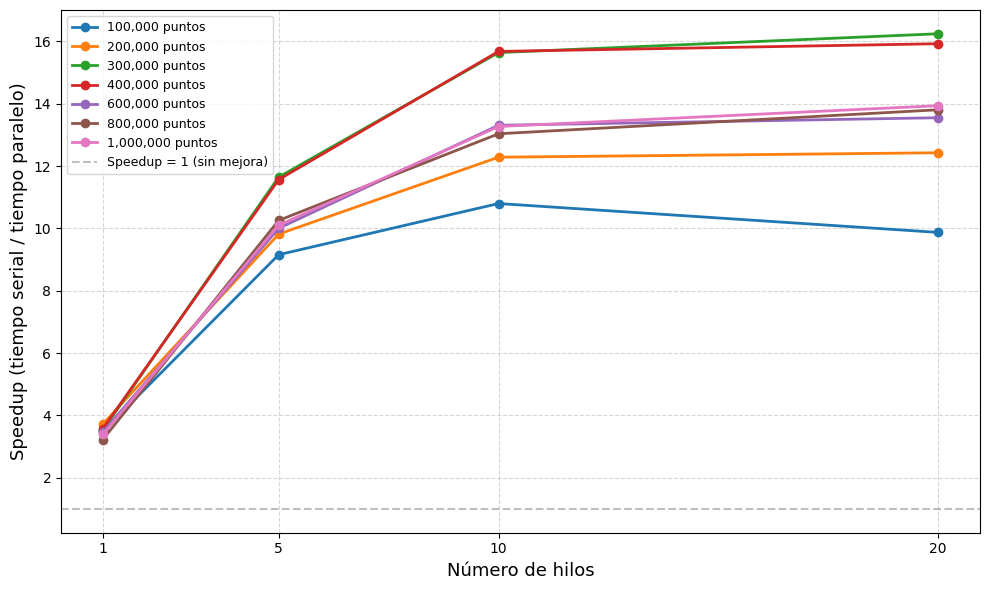

In [11]:
# Una gráfica por dimensión
for dims in [2, 3]:
    subset = merged[merged["dims"] == dims]

    plt.figure(figsize=(10, 6))

    for n in sorted(subset["puntos"].unique()):
        data = subset[subset["puntos"] == n].sort_values("hilos")
        plt.plot(data["hilos"], data["speedup"], marker="o", linewidth=2, label=f"{n:,} puntos")

    # Línea de speedup ideal (lineal)
    plt.axhline(y=1, color="gray", linestyle="--", alpha=0.5, label="Speedup = 1 (sin mejora)")

    plt.xlabel("Número de hilos", fontsize=13)
    plt.ylabel("Speedup (tiempo serial / tiempo paralelo)", fontsize=13)
    plt.xticks([1, 5, 10, 20])
    plt.legend(fontsize=9)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"speedup_{dims}d.png", dpi=150)
    plt.show()
    plt.close()


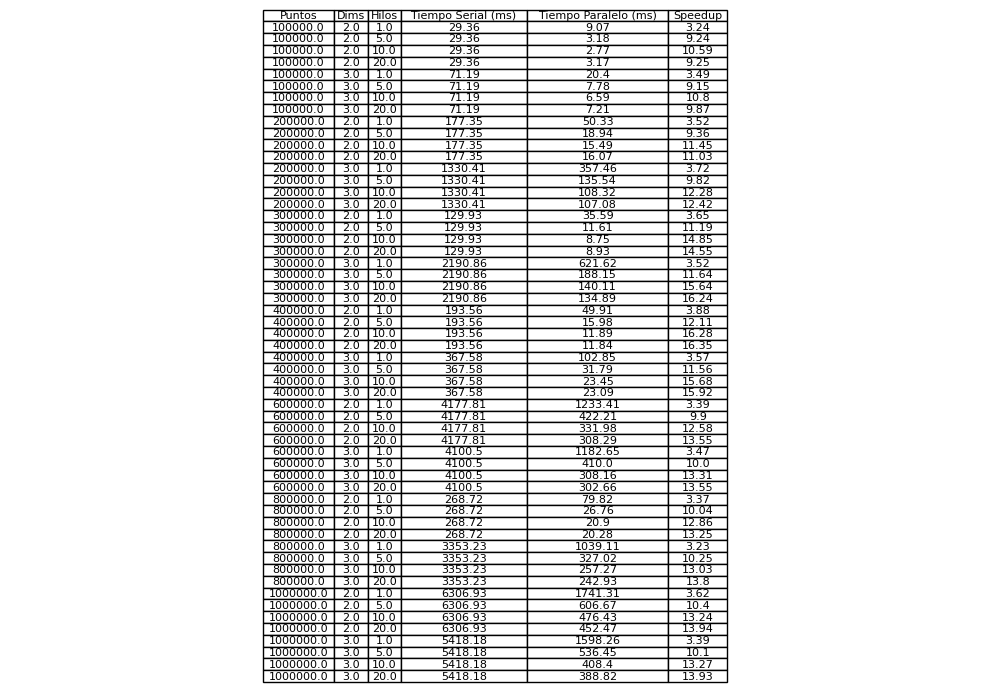

Tabla guardada: tabla_speedups.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.axis("off")

tabla_data = merged[["puntos", "dims", "hilos", "tiempo_serial", "tiempo_ms", "speedup"]].round(2)

tabla = ax.table(
    cellText=tabla_data.values,
    colLabels=["Puntos", "Dims", "Hilos", "Tiempo Serial (ms)", "Tiempo Paralelo (ms)", "Speedup"],
    cellLoc="center",
    loc="center"
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(8)
tabla.auto_set_column_width(col=list(range(len(tabla_data.columns))))

plt.tight_layout()
plt.savefig("tabla_speedups.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print("Tabla guardada: tabla_speedups.png")

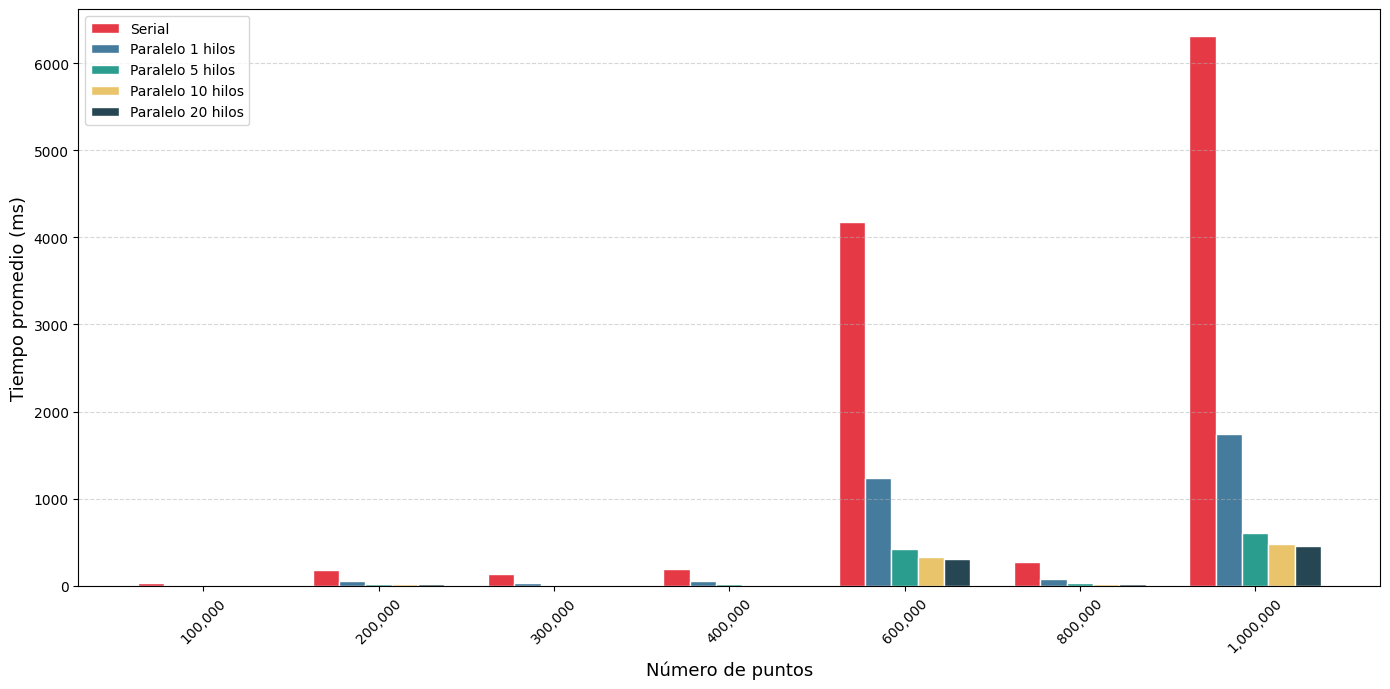

Gráfica guardada: tiempo_barras_2d.png


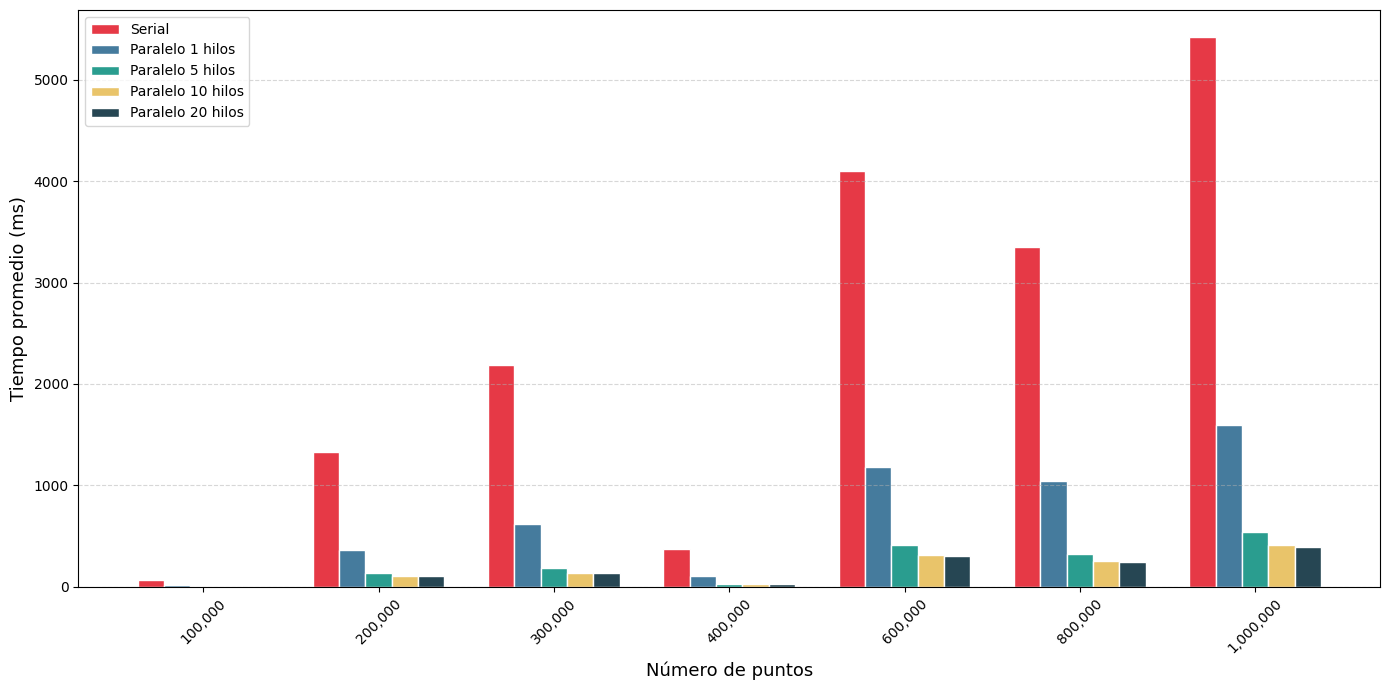

Gráfica guardada: tiempo_barras_3d.png


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("resultados.csv")

# Promediar las 10 iteraciones
promedios = df.groupby(["tipo", "puntos", "dims", "hilos"])["tiempo_ms"].mean().reset_index()

def etiqueta(row):
    if row["tipo"] == "serial":
        return "Serial"
    return f"Paralelo {int(row['hilos'])} hilos"

promedios["linea"] = promedios.apply(etiqueta, axis=1)

orden = ["Serial", "Paralelo 1 hilos", "Paralelo 5 hilos", "Paralelo 10 hilos", "Paralelo 20 hilos"]
colores = {
    "Serial":            "#e63946",
    "Paralelo 1 hilos":  "#457b9d",
    "Paralelo 5 hilos":  "#2a9d8f",
    "Paralelo 10 hilos": "#e9c46a",
    "Paralelo 20 hilos": "#264653"
}

for dims in [2, 3]:
    subset = promedios[promedios["dims"] == dims]
    puntos = sorted(subset["puntos"].unique())

    x = np.arange(len(puntos))
    ancho = 0.15  # ancho de cada barra
    n_grupos = len(orden)

    plt.figure(figsize=(14, 7))

    for i, nombre in enumerate(orden):
        data = subset[subset["linea"] == nombre].sort_values("puntos")
        if data.empty:
            continue
        offset = (i - n_grupos / 2) * ancho + ancho / 2
        plt.bar(x + offset, data["tiempo_ms"].values,
                width=ancho, label=nombre,
                color=colores[nombre], edgecolor="white")

    plt.xlabel("Número de puntos", fontsize=13)
    plt.ylabel("Tiempo promedio (ms)", fontsize=13)
    plt.xticks(x, [f"{p:,}" for p in puntos], rotation=45)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.5, axis="y")
    plt.tight_layout()
    plt.savefig(f"tiempo_barras_{dims}d.png", dpi=150)
    plt.show()
    plt.close()

    print(f"Gráfica guardada: tiempo_barras_{dims}d.png")